# Periodic XYZ Benchmark: TDVP vs TEBD vs Exact Evolution

This notebook benchmarks two ways of evolving a periodic-chain `MPS` against an exact reference:

- `TDVPEvolution(...)` with a periodic MPO Hamiltonian.
- `tebd_evolution_from_hamiltonians(...)` with an explicit periodic schedule that includes the boundary bond `(L, 1)`.
- exact dense evolution using `KrylovKit.exponentiate` on the dense state vector obtained from the `MPS`.

The notebook is split into two regimes:

1. a high-accuracy benchmark on a smaller ring, with overlaps and energy errors tracked up to `t = 10`.
2. a truncation-limited benchmark on a larger ring, where the bond dimension `chi` is intentionally small.

The code is written so the benchmark logic stays visible. Helper functions only cover model construction, exact evolution, and repeated measurement bookkeeping.

In [8]:
using Random
using Statistics
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
using KrylovKit
using MPSToolkit

default(size=(900, 600), linewidth=2, markersize=4, legend=:best)


## Shared helpers

These helpers are the reusable pieces of the benchmark:

- `periodic_xyz_mpo(...)` builds the periodic XYZ Hamiltonian as an MPO for TDVP and energy measurements.
- `periodic_xyz_matrix(...)` builds the same Hamiltonian as a dense matrix for exact evolution.
- `periodic_strang_data(...)` builds the periodic odd-even-odd Strang schedule and the matching two-site bond Hamiltonians for TEBD.
- `mps_to_vector(...)` contracts an `MPS` into a dense state vector for the exact benchmark and overlap measurements.
- `exact_trajectory(...)`, `tebd_trajectory(...)`, and `tdvp_trajectory(...)` evolve the same initial state and record overlaps, energy errors, and bond dimensions at the requested sample times.


In [9]:
function periodic_xyz_mpo(sites; Jx::Real, Jy::Real, Jz::Real)
    opsum = OpSum()
    for j in 1:(length(sites) - 1)
        opsum += Jx, "Sx", j, "Sx", j + 1
        opsum += Jy, "Sy", j, "Sy", j + 1
        opsum += Jz, "Sz", j, "Sz", j + 1
    end
    opsum += Jx, "Sx", length(sites), "Sx", 1
    opsum += Jy, "Sy", length(sites), "Sy", 1
    opsum += Jz, "Sz", length(sites), "Sz", 1
    return MPO(opsum, sites)
end

function periodic_xyz_matrix(nsites; Jx::Real, Jy::Real, Jz::Real)
    spins = spinhalf_matrices()
    locals = (
        I = Matrix{ComplexF64}(spins.I),
        Sx = Matrix{ComplexF64}(spins.Sx),
        Sy = Matrix{ComplexF64}(spins.Sy),
        Sz = Matrix{ComplexF64}(spins.Sz),
    )

    function embed_pair(left_op, left_site, right_op, right_site)
        ops = Matrix{ComplexF64}[]
        for site in 1:nsites
            if site == left_site
                push!(ops, left_op)
            elseif site == right_site
                push!(ops, right_op)
            else
                push!(ops, locals.I)
            end
        end
        result = ops[1]
        for op in ops[2:end]
            result = kron(result, op)
        end
        return result
    end

    hamiltonian = zeros(ComplexF64, 2^nsites, 2^nsites)
    for bond in 1:(nsites - 1)
        hamiltonian .+= Jx .* embed_pair(locals.Sx, bond, locals.Sx, bond + 1)
        hamiltonian .+= Jy .* embed_pair(locals.Sy, bond, locals.Sy, bond + 1)
        hamiltonian .+= Jz .* embed_pair(locals.Sz, bond, locals.Sz, bond + 1)
    end
    hamiltonian .+= Jx .* embed_pair(locals.Sx, nsites, locals.Sx, 1)
    hamiltonian .+= Jy .* embed_pair(locals.Sy, nsites, locals.Sy, 1)
    hamiltonian .+= Jz .* embed_pair(locals.Sz, nsites, locals.Sz, 1)
    return hamiltonian
end

function random_product_state(sites, rng)
    tensors = ITensor[]
    for site in sites
        theta = acos(2rand(rng) - 1)
        phi = 2pi * rand(rng)
        tensor = ITensor(ComplexF64, site)
        tensor[site => 1] = cos(theta / 2)
        tensor[site => 2] = exp(1im * phi) * sin(theta / 2)
        push!(tensors, tensor)
    end
    return MPS(tensors)
end

function vector_energy_density(state::AbstractVector, hamiltonian::AbstractMatrix, nsites::Integer)
    return real(state' * (hamiltonian * state)) / nsites
end

function mps_to_vector(psi::MPS)
    state_tensor = psi[1]
    for site in 2:length(psi)
        state_tensor *= psi[site]
    end
    physical_sites = [siteind(psi, site) for site in 1:length(psi)]
    return vec(Array(state_tensor, physical_sites...))
end


function periodic_strang_data(nsites; Jx::Real, Jy::Real, Jz::Real)
    odd_bonds = collect(1:2:(nsites - 1))
    even_bonds = collect(2:2:nsites)
    schedule = vcat(odd_bonds, even_bonds, odd_bonds)
    weights = vcat(
        fill(0.5, length(odd_bonds)),
        fill(1.0, length(even_bonds)),
        fill(0.5, length(odd_bonds)),
    )
    bond_hamiltonians = [
        weight * spinhalf_xyz_bond_hamiltonian(; Jx=Jx, Jy=Jy, Jz=Jz)
        for weight in weights
    ]
    return schedule, bond_hamiltonians
end

function exact_trajectory(reference_vector, dense_hamiltonian, sample_times)
    vectors = Vector{Vector{ComplexF64}}(undef, length(sample_times))
    vectors[1] = copy(reference_vector)
    for idx in 2:length(sample_times)
        delta_t = sample_times[idx] - sample_times[idx - 1]
        vectors[idx], info = exponentiate(dense_hamiltonian, -1im * delta_t, vectors[idx - 1])
        @assert info.converged == 1
    end
    return vectors
end

function tebd_trajectory(reference, mpo_hamiltonian, dense_hamiltonian, exact_vectors, sample_times;
    dt::Real,
    schedule,
    bond_hamiltonians,
    maxdim::Integer,
    cutoff::Real,
)
    sample_steps = round.(Int, sample_times ./ dt)
    evolution = tebd_evolution_from_hamiltonians(
        bond_hamiltonians,
        dt;
        schedule=schedule,
        maxdim=maxdim,
        cutoff=cutoff,
    )
    psi = copy(reference)
    overlaps = zeros(Float64, length(sample_times))
    energy_errors = zeros(Float64, length(sample_times))
    linkdims = zeros(Int, length(sample_times))
    overlaps[1] = 1.0
    energy_errors[1] = abs(energy_density(psi, mpo_hamiltonian) - vector_energy_density(exact_vectors[1], dense_hamiltonian, length(psi)))
    linkdims[1] = maxlinkdim(psi)

    wall_time = @elapsed begin
        for idx in 2:length(sample_times)
            for _ in 1:(sample_steps[idx] - sample_steps[idx - 1])
                evolve!(psi, evolution)
            end
            overlaps[idx] = abs2(exact_vectors[idx]' * mps_to_vector(psi))
            energy_errors[idx] = abs(energy_density(psi, mpo_hamiltonian) - vector_energy_density(exact_vectors[idx], dense_hamiltonian, length(psi)))
            linkdims[idx] = maxlinkdim(psi)
        end
    end
    return (; psi, overlaps, energy_errors, linkdims, wall_time)
end

function tdvp_trajectory(reference, mpo_hamiltonian, dense_hamiltonian, exact_vectors, sample_times;
    dt::Real,
    maxdim::Integer,
    cutoff::Real,
)
    sample_steps = round.(Int, sample_times ./ dt)
    evolution = TDVPEvolution(
        mpo_hamiltonian,
        -1im * dt;
        time_step=-1im * dt,
        nsteps=1,
        normalize=true,
        solver_kwargs=(maxdim=maxdim, cutoff=cutoff),
    )
    psi = copy(reference)
    overlaps = zeros(Float64, length(sample_times))
    energy_errors = zeros(Float64, length(sample_times))
    linkdims = zeros(Int, length(sample_times))
    overlaps[1] = 1.0
    energy_errors[1] = abs(energy_density(psi, mpo_hamiltonian) - vector_energy_density(exact_vectors[1], dense_hamiltonian, length(psi)))
    linkdims[1] = maxlinkdim(psi)

    wall_time = @elapsed begin
        for idx in 2:length(sample_times)
            for _ in 1:(sample_steps[idx] - sample_steps[idx - 1])
                evolve!(psi, evolution)
            end
            overlaps[idx] = abs2(exact_vectors[idx]' * mps_to_vector(psi))
            energy_errors[idx] = abs(energy_density(psi, mpo_hamiltonian) - vector_energy_density(exact_vectors[idx], dense_hamiltonian, length(psi)))
            linkdims[idx] = maxlinkdim(psi)
        end
    end
    return (; psi, overlaps, energy_errors, linkdims, wall_time)
end



tdvp_trajectory (generic function with 1 method)

## High-accuracy regime: `L = 8`, `chi = 64`

This first regime is the one where the periodic TEBD boundary-gate path should work very well. The sample times go out to `t = 10` with spacing `0.25`, so the overlap and energy curves are dense enough to show drift if it appears.

Key parameters used below:

- `nsites = 8`: small enough that exact evolution is still cheap.
- `dt = 0.05`: one full TEBD/TDVP sweep per time step.
- `sample_times = 0:0.25:10`: denser checkpoints than the original single-final-time script.
- `maxdim = 64`: large enough that the benchmark is close to the high-accuracy regime rather than the truncation-limited regime.
- `cutoff = 1e-10`: compression tolerance for both TEBD and TDVP.


In [10]:
Random.seed!(11)

Jx = 0.9
Jy = 1.0
Jz = 0.35
high_accuracy_nsites = 8
high_accuracy_dt = 0.05
high_accuracy_maxdim = 64
high_accuracy_cutoff = 1e-10
high_accuracy_times = collect(0.0:0.25:10.0)

high_accuracy_sites = siteinds("S=1/2", high_accuracy_nsites)
high_accuracy_reference = random_product_state(high_accuracy_sites, Random.default_rng())
high_accuracy_mpo = periodic_xyz_mpo(high_accuracy_sites; Jx=Jx, Jy=Jy, Jz=Jz)
dense_hamiltonian = periodic_xyz_matrix(high_accuracy_nsites; Jx=Jx, Jy=Jy, Jz=Jz)
schedule, bond_hamiltonians = periodic_strang_data(high_accuracy_nsites; Jx=Jx, Jy=Jy, Jz=Jz)

high_accuracy_exact = exact_trajectory(
    mps_to_vector(high_accuracy_reference),
    dense_hamiltonian,
    high_accuracy_times,
)

high_accuracy_tebd = tebd_trajectory(
    high_accuracy_reference,
    high_accuracy_mpo,
    dense_hamiltonian,
    high_accuracy_exact,
    high_accuracy_times;
    dt=high_accuracy_dt,
    schedule=schedule,
    bond_hamiltonians=bond_hamiltonians,
    maxdim=high_accuracy_maxdim,
    cutoff=high_accuracy_cutoff,
)

high_accuracy_tdvp = tdvp_trajectory(
    high_accuracy_reference,
    high_accuracy_mpo,
    dense_hamiltonian,
    high_accuracy_exact,
    high_accuracy_times;
    dt=high_accuracy_dt,
    maxdim=high_accuracy_maxdim,
    cutoff=high_accuracy_cutoff,
)

println("TEBD final overlap = ", high_accuracy_tebd.overlaps[end])
println("TDVP final overlap = ", high_accuracy_tdvp.overlaps[end])
println("TEBD wall time = ", high_accuracy_tebd.wall_time)
println("TDVP wall time = ", high_accuracy_tdvp.wall_time)


TEBD final overlap = 0.9999998535412771
TDVP final overlap = 0.9974518003566083
TEBD wall time = 1.305837666
TDVP wall time = 23.912857458


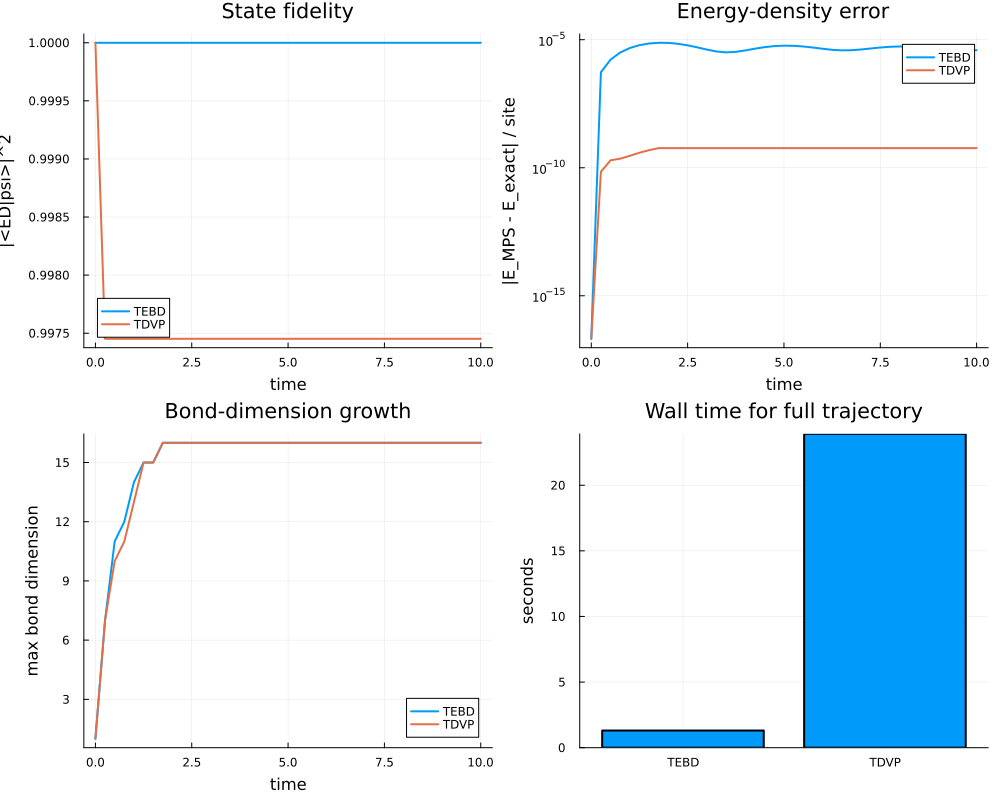

print device already activated


In [11]:
high_accuracy_plots = plot(layout=(2, 2), size=(1000, 800))

plot!(
    high_accuracy_plots[1],
    high_accuracy_times,
    high_accuracy_tebd.overlaps;
    label="TEBD",
    xlabel="time",
    ylabel="|<ED|psi>|^2",
    title="State fidelity",
)
plot!(
    high_accuracy_plots[1],
    high_accuracy_times,
    high_accuracy_tdvp.overlaps;
    label="TDVP",
)

plot!(
    high_accuracy_plots[2],
    high_accuracy_times,
    high_accuracy_tebd.energy_errors;
    label="TEBD",
    xlabel="time",
    ylabel="|E_MPS - E_exact| / site",
    yscale=:log10,
    title="Energy-density error",
)
plot!(
    high_accuracy_plots[2],
    high_accuracy_times,
    high_accuracy_tdvp.energy_errors;
    label="TDVP",
)

plot!(
    high_accuracy_plots[3],
    high_accuracy_times,
    high_accuracy_tebd.linkdims;
    label="TEBD",
    xlabel="time",
    ylabel="max bond dimension",
    title="Bond-dimension growth",
)
plot!(
    high_accuracy_plots[3],
    high_accuracy_times,
    high_accuracy_tdvp.linkdims;
    label="TDVP",
)

bar!(
    high_accuracy_plots[4],
    ["TEBD", "TDVP"],
    [high_accuracy_tebd.wall_time, high_accuracy_tdvp.wall_time];
    ylabel="seconds",
    title="Wall time for full trajectory",
    label="",
)

display(high_accuracy_plots)


## Truncation-limited regime: `L = 12`, smaller `chi`

This section changes the question. Instead of asking which method is best in the nearly converged regime, it asks what happens when the ring is larger and the allowed bond dimension is intentionally small.

Parameters used here:

- `nsites = 12`: still small enough for exact evolution, but much harder for the MPS methods.
- `total_time = 5.0`: long enough to accumulate truncation error without making the exact reference too expensive.
- `chi_values = [8, 12, 16]`: a deliberately tight bond-dimension budget.

This is the regime where TDVP was observed to be more robust than TEBD in the earlier command-line benchmark.

In [12]:
truncation_nsites = 12
truncation_dt = 0.05
truncation_total_time = 5.0
truncation_maxdims = [8, 12, 16]
truncation_cutoff = 1e-10

truncation_sites = siteinds("S=1/2", truncation_nsites)
truncation_reference = random_product_state(truncation_sites, MersenneTwister(11))
truncation_mpo = periodic_xyz_mpo(truncation_sites; Jx=Jx, Jy=Jy, Jz=Jz)
truncation_dense = periodic_xyz_matrix(truncation_nsites; Jx=Jx, Jy=Jy, Jz=Jz)
truncation_schedule, truncation_bonds = periodic_strang_data(truncation_nsites; Jx=Jx, Jy=Jy, Jz=Jz)
truncation_exact = exact_trajectory(
    mps_to_vector(truncation_reference),
    truncation_dense,
    [0.0, truncation_total_time],
)

truncation_tebd_overlap = Float64[]
truncation_tdvp_overlap = Float64[]
truncation_tebd_energy = Float64[]
truncation_tdvp_energy = Float64[]
truncation_tebd_runtime = Float64[]
truncation_tdvp_runtime = Float64[]

for chi in truncation_maxdims
    tebd_data = tebd_trajectory(
        truncation_reference,
        truncation_mpo,
        truncation_dense,
        truncation_exact,
        [0.0, truncation_total_time];
        dt=truncation_dt,
        schedule=truncation_schedule,
        bond_hamiltonians=truncation_bonds,
        maxdim=chi,
        cutoff=truncation_cutoff,
    )
    tdvp_data = tdvp_trajectory(
        truncation_reference,
        truncation_mpo,
        truncation_dense,
        truncation_exact,
        [0.0, truncation_total_time];
        dt=truncation_dt,
        maxdim=chi,
        cutoff=truncation_cutoff,
    )
    push!(truncation_tebd_overlap, tebd_data.overlaps[end])
    push!(truncation_tdvp_overlap, tdvp_data.overlaps[end])
    push!(truncation_tebd_energy, tebd_data.energy_errors[end])
    push!(truncation_tdvp_energy, tdvp_data.energy_errors[end])
    push!(truncation_tebd_runtime, tebd_data.wall_time)
    push!(truncation_tdvp_runtime, tdvp_data.wall_time)
end

println("TEBD overlaps = ", truncation_tebd_overlap)
println("TDVP overlaps = ", truncation_tdvp_overlap)


TEBD overlaps = [0.48525762617676577, 0.7236912208313777, 0.8532934170147958]
TDVP overlaps = [0.6235807474564116, 0.792379806923854, 0.8766407392010742]


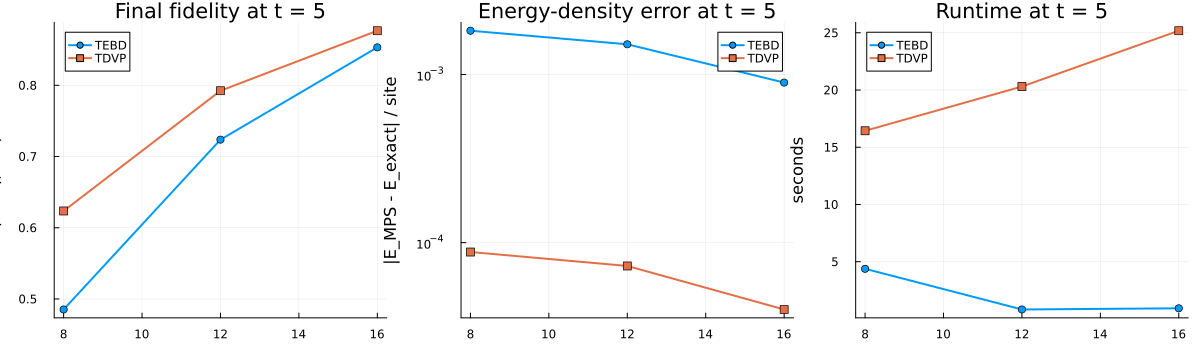

In [13]:
truncation_plots = plot(layout=(1, 3), size=(1200, 350))

plot!(
    truncation_plots[1],
    truncation_maxdims,
    truncation_tebd_overlap;
    marker=:circle,
    label="TEBD",
    xlabel="maxdim",
    ylabel="|<ED|psi>|^2",
    title="Final fidelity at t = 5",
)
plot!(
    truncation_plots[1],
    truncation_maxdims,
    truncation_tdvp_overlap;
    marker=:square,
    label="TDVP",
)

plot!(
    truncation_plots[2],
    truncation_maxdims,
    truncation_tebd_energy;
    marker=:circle,
    label="TEBD",
    xlabel="maxdim",
    ylabel="|E_MPS - E_exact| / site",
    yscale=:log10,
    title="Energy-density error at t = 5",
)
plot!(
    truncation_plots[2],
    truncation_maxdims,
    truncation_tdvp_energy;
    marker=:square,
    label="TDVP",
)

plot!(
    truncation_plots[3],
    truncation_maxdims,
    truncation_tebd_runtime;
    marker=:circle,
    label="TEBD",
    xlabel="maxdim",
    ylabel="seconds",
    title="Runtime at t = 5",
)
plot!(
    truncation_plots[3],
    truncation_maxdims,
    truncation_tdvp_runtime;
    marker=:square,
    label="TDVP",
)

display(truncation_plots)


## Reading the results

The two sections answer different questions:

- In the high-accuracy regime, periodic TEBD with the explicit boundary bond can track the exact evolution very closely, and the fidelity curve shows whether it stays that way out to long times.
- In the truncation-limited regime, the bond dimension becomes the main bottleneck, and the overlap curves show whether TEBD or TDVP degrades more gracefully.

If you want to push the benchmark further, the main knobs to change are:

- `high_accuracy_times` if you want denser or longer trajectories.
- `truncation_maxdims` if you want to see the crossover into a better-converged regime.
- `Jx`, `Jy`, `Jz`, or the random seed if you want a more or less entangling periodic benchmark.
